## 7.3 전자구조 계산: 완전 활성 공간 자기무리장(CASSCF) 방법

In [14]:
from qiskit import transpile
from qiskit.primitives import StatevectorEstimator  # 호환성 수정: V1 Estimator → V2 StatevectorEstimator
from qiskit.circuit.library import TwoLocal
from qiskit.quantum_info import SparsePauliOp
from qiskit_algorithms import VQE
from scipy.optimize import minimize
import numpy as np
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_bloch_multivector, plot_state_city, plot_histogram
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
import koreanize_matplotlib

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [15]:
# 활성 공간의 2전자 계를 위한 단순화 해밀토니안 정의
pauli_list = [
    ('II', -1.0),
    ('ZI',  0.4),
    ('IZ', -0.4),
    ('ZZ', -0.1),
    ('XX',  0.2)
]

In [16]:
# SparsePauliOp 객체로 변환
hamiltonian = SparsePauliOp.from_list(pauli_list)

In [17]:
# 활성 공간용 앤사츠 정의 (R_y 회전 + CZ 얽힘, 전체 얽힘, reps=2)
ansatz = TwoLocal(rotation_blocks='ry', entanglement_blocks='cz', entanglement='full', reps=2)

In [18]:
# 양자 시뮬레이터 설정
simulator = AerSimulator()

In [19]:
# VQE 알고리즘 구성
estimator = StatevectorEstimator()  # 호환성 수정: V2 추정기
vqe = VQE(estimator=estimator, ansatz=ansatz, optimizer=minimize)

In [20]:
# VQE 실행
result = vqe.compute_minimum_eigenvalue(operator=hamiltonian)

In [21]:
# 결과 출력
print("CASSCF 바닥상태 에너지: ", result.eigenvalue.real)
print("최적 매개변수: ", result.optimal_parameters)

CASSCF 바닥상태 에너지:  -1.7246211251148247
최적 매개변수:  {ParameterVectorElement(θ[0]): np.float64(-0.4882931425204431), ParameterVectorElement(θ[1]): np.float64(-0.4538611721130272), ParameterVectorElement(θ[2]): np.float64(-2.8993803474518414), ParameterVectorElement(θ[3]): np.float64(3.7809549323824783), ParameterVectorElement(θ[4]): np.float64(2.986402793684626), ParameterVectorElement(θ[5]): np.float64(6.475423190356104)}


In [22]:
# VQE가 찾은 매개변수로 최적 회로 생성
optimal_circuit = ansatz.assign_parameters(result.optimal_parameters)

In [23]:
# 시뮬레이터용으로 회로 트랜스파일
transpiled_circuit = transpile(optimal_circuit, simulator)

In [24]:
# 회로를 실행해 최종 상태벡터 획득
transpiled_circuit.save_statevector()
result = simulator.run(transpiled_circuit).result()
state = result.get_statevector()

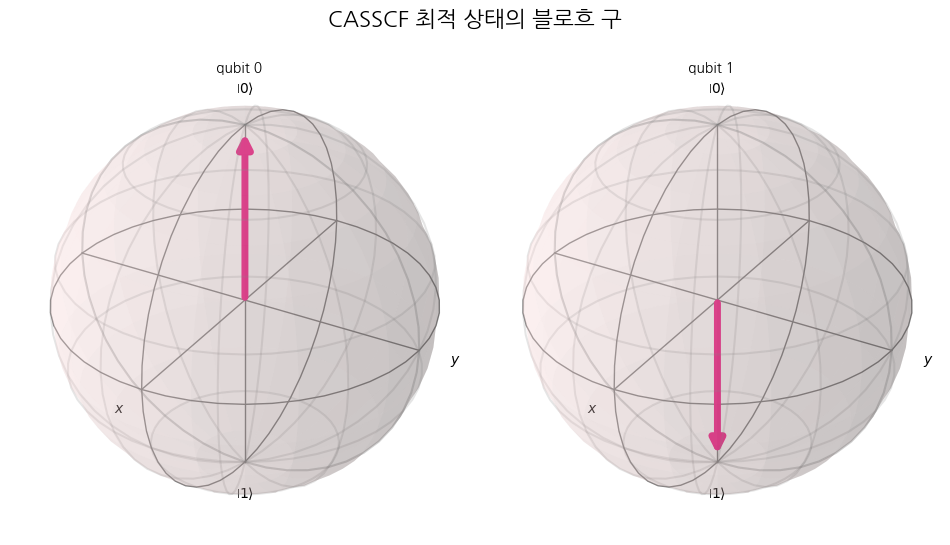

In [25]:
# 첫 큐비트의 블로흐 벡터 그리기
plot_bloch_multivector(state, title="CASSCF 최적 상태의 블로흐 구")
plt.show()  # 호환성 수정

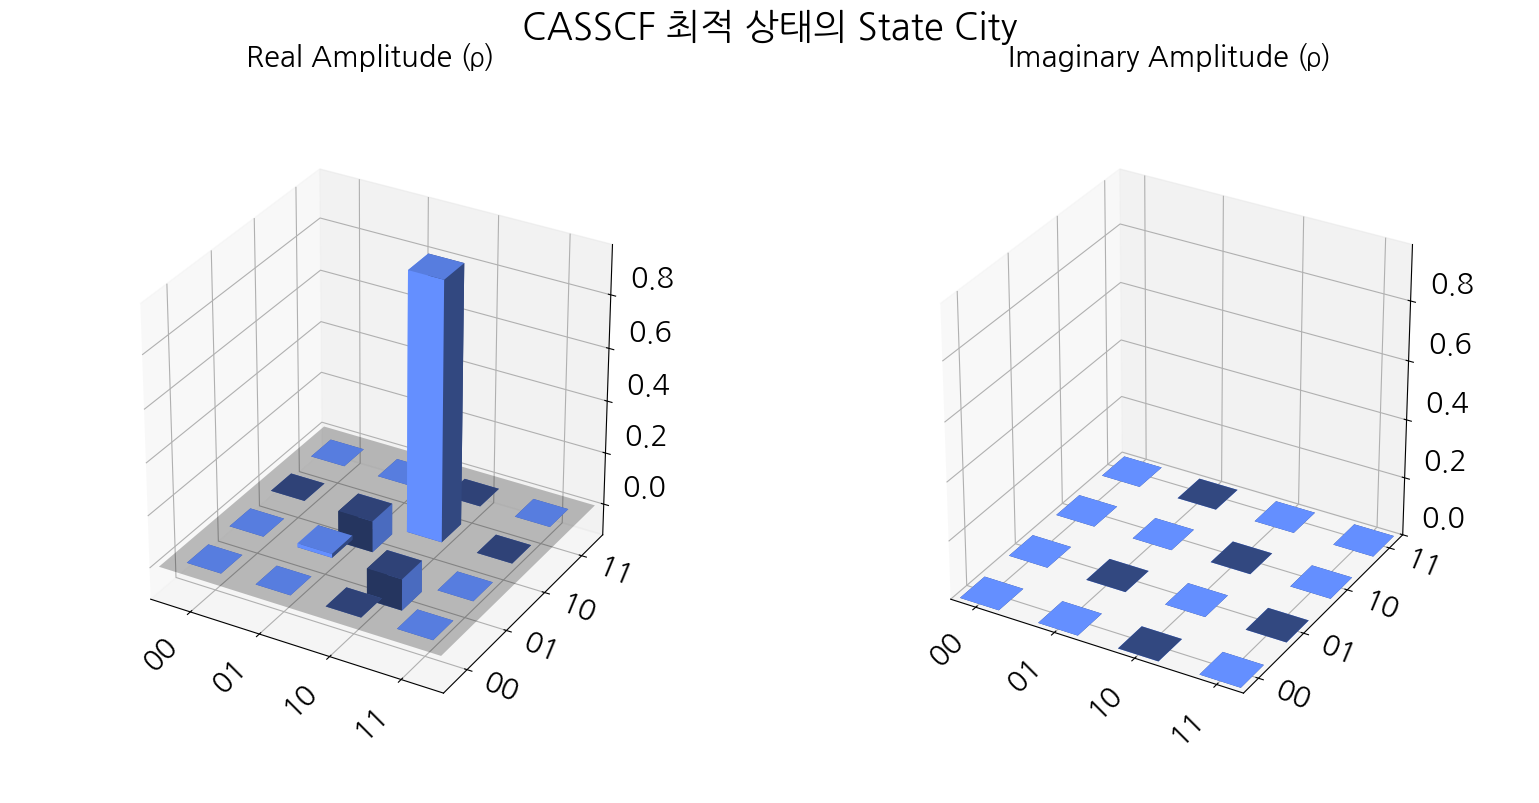

In [26]:
# state_city로 상태 시각화
plot_state_city(state, title="CASSCF 최적 상태의 State City")
plt.show()  # 호환성 수정

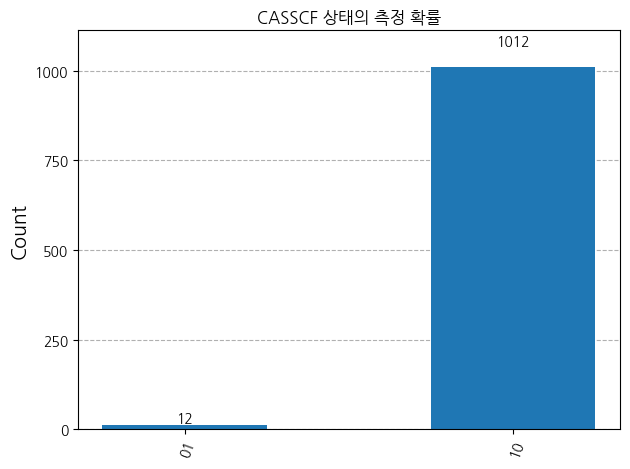

In [27]:
# 측정 확률을 히스토그램으로 계산·시각화
transpiled_circuit.measure_all()
counts = simulator.run(transpiled_circuit).result().get_counts()
plot_histogram(counts, title="CASSCF 상태의 측정 확률")
plt.show()  # 호환성 수정